# Gaussian M1–M4 comparison across diagnostics

Each error metric is shown as a 4×4 grid. Rows are assumed models M1, M2, M3, and M4; columns are the L2, Linf, density, and Kernel diagnostics. Colors, markers, medians, calibration bands, scales, and legends follow `summary_dimension_comparison all S.ipynb`. X-axis labels appear only on the bottom row, and the y-axis has one shared figure label.

The layout extends `summary_dimension_comparison_M1_M3_2x4.ipynb` to all four assumed models. Each panel overlays S=D, S=2D, and S=4D. Figure height increases to keep individual panels readable; the reference styles and error normalization settings are retained.


In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys

PROJECT_ROOT = Path("/Users/yimingzang/Documents/Project/benchmark2")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from benchmark.examples.gaussian.config import ASSUMED_MODELS, SOURCE_MODELS
from benchmark.examples.gaussian.analysis.summary_dimension_data import (
    DIAGNOSTICS,
    SUMMARY_COLORS,
    load_comparison_data,
)


# Lightweight plotting constants copied from summry_diagnostic.py. Importing that
# full analysis module would unnecessarily require TensorFlow for this plot-only notebook.
sd = SimpleNamespace(
    ASSUMED_MODELS=ASSUMED_MODELS,
    SOURCE_MODELS=SOURCE_MODELS,
    SOURCE_COLORS=(
        "#F0E442", "#E69F00", "#009E73", "#CC79A7",
        "#56B4E9", "#D55E00", "#0072B2", "#E011CF",
        "#999999", "#1F03EE", "#882255", "#44AA99",
    ),
    TYPICAL_SET_FILL="#DCEEDC",
    DIAGNOSTIC_XLABELS={
        "l2": r"Diagnostic: $L_2$-based",
        "linf": r"Diagnostic: $L_\infty$-based",
        "mmd": "Diagnostic: Kernel-based",
        "density": "Diagnostic: density-based",
    },
)


In [2]:
PROJECT_DIR = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
OUTPUT_DIR = PROJECT_DIR / "results" / "plots" / "summary_dimension_M1_M4_4x4"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Keep the requested row and column order explicit.
PLOT_MODELS = ("m1", "m2", "m3", "m4")
PLOT_DIAGNOSTICS = ("l2", "linf", "density", "mmd")

# True divides each error by its calibrated threshold scale.
# False preserves the raw NPE-versus-analytical error units.
NORMALIZE_BY_CALIBRATION_THRESHOLD = False

# Y-axis display settings (calibration threshold values are unchanged).
# scale: "linear" or "symlog".
# linthresh: half-width of the linear interval around zero, in displayed units.
# linscale: increase to give that interval more vertical space (try 2, 3, 4).
# nticks: approximate number of evenly spaced, rounded major tick labels.
Y_AXIS_SETTINGS = {
    "log10_logml_error": dict(scale="symlog", linthresh=0.1, linscale=3.0, nticks=7),
    "pmp_error": dict(scale="symlog", linthresh=0.1, linscale=3.0, nticks=7),
}

comparison_data = load_comparison_data(
    diagnostics=PLOT_DIAGNOSTICS,
    error_metrics=("posterior_mmd", "log10_logml_error", "pmp_error"),
)

comparison_data.groupby(
    ["error_metric", "diagnostic", "summary", "assumed_model"],
    observed=True,
).size().rename("n_rows")


error_metric   diagnostic  summary  assumed_model
posterior_mmd  l2          S=D      m1               600
                                    m2               600
                                    m3               600
                                    m4               600
                           S=2D     m1               600
                                                    ... 
pmp_error      mmd         S=2D     m4               600
                           S=4D     m1               600
                                    m2               600
                                    m3               600
                                    m4               600
Name: n_rows, Length: 144, dtype: int64

In [3]:
source_color = dict(zip(sd.SOURCE_MODELS, sd.SOURCE_COLORS, strict=False))
class_styles = {
    False: {"marker": "o", "size": 40, "label": "all high surprise"},
    True: {"marker": "D", "size": 60, "label": "at least one not high surprise"},
}

def scatter_by_class_and_source(ax, data, x, y):
    for flag, style in class_styles.items():
        group = data[data["at_least_one_not_extrapolative"] == flag]
        ax.scatter(
            x.loc[group.index],
            y.loc[group.index],
            c=group["source_model"].map(source_color),
            marker=style["marker"],
            s=style["size"],
            alpha=0.75,
            edgecolors="black",
            linewidths=0.55,
        )

def scatter_by_class_and_summary(ax, summary, data, x, y):
    color = SUMMARY_COLORS[summary]
    for flag, style in class_styles.items():
        group = data[data["at_least_one_not_extrapolative"] == flag]
        ax.scatter(
            x.loc[group.index],
            y.loc[group.index],
            color=color,
            marker=style["marker"],
            s=style["size"],
            alpha=0.62,
            edgecolors="black",
            linewidths=0.45,
        )

SUMMARY_POINT_SIZE = 42
SUMMARY_MEDIAN_SIZE = 96
WELL_SPECIFIED_MEDIAN_SIZE = 132
SUMMARY_RAW_ALPHA = 0.28
source_shape_styles = {
    True: {
        "marker": "^",
        "dataset_label": "well-specified datasets",
        "median_label": "well-specified median",
    },
    False: {
        "marker": "o",
        "dataset_label": "other simulated datasets",
        "median_label": "other simulated median",
    },
}

def scatter_summary_with_source_medians(ax, summary, data, x, y):
    color = SUMMARY_COLORS[summary]
    is_well_specified = data["source_model"].eq(data["assumed_model"])
    for well_specified, style in source_shape_styles.items():
        group = data[is_well_specified.eq(well_specified)]
        if group.empty:
            continue
        ax.scatter(
            x.loc[group.index], y.loc[group.index],
            color=color, marker=style["marker"],
            s=SUMMARY_POINT_SIZE, alpha=SUMMARY_RAW_ALPHA,
            edgecolors="none", linewidths=0.0, zorder=3,
        )
    for source in sd.SOURCE_MODELS:
        group = data[data["source_model"].eq(source)]
        if group.empty:
            continue
        x_values = x.loc[group.index]
        y_values = y.loc[group.index]
        well_specified = bool(
            group["source_model"].eq(group["assumed_model"]).all()
        )
        ax.scatter(
            [x_values.median()], [y_values.median()],
            color=color, marker=source_shape_styles[well_specified]["marker"],
            s=(WELL_SPECIFIED_MEDIAN_SIZE if well_specified else SUMMARY_MEDIAN_SIZE),
            alpha=1.0,
            edgecolors="black", linewidths=0.65, zorder=6,
        )

def add_first_large_error(ax, data, x, y, error_bound=0.05):
    if error_bound is None or data.empty:
        return
    ordered = pd.DataFrame({"x": x.loc[data.index], "y": y.loc[data.index]}).dropna().sort_values("x")
    hit = ordered[np.abs(ordered["y"]) > error_bound].head(1)
    if hit.empty:
        return
    x0 = float(hit["x"].iloc[0])
    ax.axvline(x0, color="0.2", linestyle=":", linewidth=1.2)
    ax.text(x0, 0.96, f"{x0:.2g}", transform=ax.get_xaxis_transform(), ha="right", va="top", rotation=90, fontsize=20)

def max_pmp_error_within_rho(data, model, rho_max=1.0):
    rho = data[f"d_{model}"] / data[f"dm_high_{model}"]
    error = data[f"signed_pmp_error_npe_{model}"]
    subset = (
        data.assign(_rho=rho, _error=error)
        .loc[lambda df: df["_rho"].le(rho_max)]
        .dropna(subset=["_rho", "_error"])
    )
    if subset.empty:
        return None
    row = subset.loc[subset["_error"].abs().idxmax()]
    return {
        "source_model": row["source_model"],
        "rho_at_error": float(row["_rho"]),
        "signed_error_within_rho": float(row["_error"]),
        "n_candidate_points": int(len(subset)),
    }

def collect_max_pmp_error_within_rho(pmp_by_panel, rho_max=1.0):
    rows = []
    for panel_label, data in pmp_by_panel.items():
        for model in sd.ASSUMED_MODELS:
            best = max_pmp_error_within_rho(data, model, rho_max=rho_max)
            if best is None:
                continue
            rows.append({
                "panel_label": panel_label,
                "assumed_model": model,
                "rho_max": float(rho_max),
                **best,
            })
    return pd.DataFrame(rows)

def add_rho_max_error_line(ax, rho_error_df, panel_label, model):
    if rho_error_df is None or rho_error_df.empty:
        return
    match = rho_error_df[
        rho_error_df["panel_label"].eq(panel_label)
        & rho_error_df["assumed_model"].eq(model)
    ]
    if match.empty:
        return
    y0 = float(match["signed_error_within_rho"].iloc[0])
    ax.axhline(y0, color="#882255", linestyle="--", linewidth=1.1)
    va = "bottom" if y0 >= 0 else "top"
    ax.text(
        0.98,
        y0,
        f"{y0:.2g}",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va=va,
        fontsize=15,
        color="#882255",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 1.0},
    )

def add_distance_regions(ax, low, high, x_min, x_max):
    del x_min, x_max
    ax.axvspan(low, high, color=sd.TYPICAL_SET_FILL, alpha=0.70, zorder=0)
    ax.axvline(high, color="0.25", linestyle="--", linewidth=0.9, zorder=1)

def add_facet_strips(fig, axes, col_labels=None, row_labels=None):
    axes = np.atleast_2d(axes)
    strip_color = "0.85"
    edge_color = "0.35"
    pad = 0.004
    top_h = 0.55 / fig.get_figheight()
    right_w = 0.058

    if col_labels is not None:
        for ax, label in zip(axes[0], col_labels, strict=False):
            pos = ax.get_position()
            strip = fig.add_axes([pos.x0, pos.y1 + pad, pos.width, top_h])
            strip.set_facecolor(strip_color)
            strip.text(0.5, 0.5, label, ha="center", va="center", fontsize=21)
            strip.set_xticks([])
            strip.set_yticks([])
            for spine in strip.spines.values():
                spine.set_color(edge_color)

    if row_labels is not None:
        for ax, label in zip(axes[:, -1], row_labels, strict=False):
            pos = ax.get_position()
            strip = fig.add_axes([pos.x1 + pad, pos.y0, right_w, pos.height])
            strip.set_facecolor(strip_color)
            strip.text(0.5, 0.5, label, rotation=-90, ha="center", va="center", fontsize=19, linespacing=1.05)
            strip.set_xticks([])
            strip.set_yticks([])
            for spine in strip.spines.values():
                spine.set_color(edge_color)

def legend_handles():
    class_handles = [
        Line2D([0], [0], marker=style["marker"], color="none", markerfacecolor="0.55", markeredgecolor="black", markersize=12, label=style["label"])
        for style in class_styles.values()
    ]
    model_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=source_color[source], markeredgecolor="black", markersize=11, label=source.upper())
        for source in sd.SOURCE_MODELS
    ]
    return class_handles, model_handles

def median_handle():
    return Line2D([0], [0], marker="*", color="none", markerfacecolor="white",
                  markeredgecolor="black", markersize=23, label="source median")

def summary_handles():
    return [
        Line2D(
            [0], [0], color=color, linewidth=5, label=summary,
        )
        for summary, color in SUMMARY_COLORS.items()
    ]

def source_shape_handles():
    handles = []
    for style in source_shape_styles.values():
        handles.extend([
            Line2D(
                [0], [0], marker=style["marker"], color="none",
                markerfacecolor="0.45", markeredgecolor="none",
                markersize=10, alpha=SUMMARY_RAW_ALPHA,
                label=style["dataset_label"],
            ),
            Line2D(
                [0], [0], marker=style["marker"], color="none",
                markerfacecolor="0.45", markeredgecolor="black",
                markeredgewidth=0.65,
                markersize=(15 if style["marker"] == "^" else 12),
                alpha=1.0,
                label=style["median_label"],
            ),
        ])
    return handles

def add_summary_bottom_legend(
    fig, include_class=False, include_median=False
):
    handles = summary_handles()
    if include_class:
        class_handles, _ = legend_handles()
        handles.extend(class_handles)
    if include_median:
        handles.extend(source_shape_handles())
    fig.legend(
        handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.3125 / fig.get_figheight()),
        ncol=len(handles), frameon=False, fontsize=18, markerscale=1.1,
    )

def add_bottom_legend(fig, include_class=True, include_median=False):
    class_handles, model_handles = legend_handles()
    if include_class:
        fig.legend(handles=class_handles, loc="lower center", bbox_to_anchor=(0.5, 0.075), ncol=2, frameon=False, fontsize=19, markerscale=1.1)
        model_y = 0.0
    else:
        model_y = 0.035
    handles = model_handles + ([median_handle()] if include_median else [])
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, model_y), ncol=len(handles), frameon=False, fontsize=19, markerscale=1.1)

def add_right_legend(fig, x=0.84):
    class_handles, model_handles = legend_handles()
    fig.legend(handles=class_handles, loc="center left", bbox_to_anchor=(x, 0.62), ncol=1, frameon=False, fontsize=19, markerscale=1.1)
    fig.legend(handles=model_handles, loc="center left", bbox_to_anchor=(x, 0.34), ncol=2, frameon=False, fontsize=19, markerscale=1.1)

def style_panel_grid(fig, axes, xlabel_by_col, ylabel, row_labels, col_labels, include_class_legend=True, include_median_legend=False):
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=17)
        ax.xaxis.label.set_size(19)
        ax.yaxis.label.set_size(19)

    for ax, xlabel in zip(axes[-1], xlabel_by_col, strict=False):
        ax.set_xlabel(xlabel)

    fig.supylabel(ylabel, x=0.035, fontsize=22)
    add_facet_strips(fig, axes, col_labels=col_labels, row_labels=row_labels)
    add_bottom_legend(fig, include_class=include_class_legend, include_median=include_median_legend)


def style_summary_overlay_panels(
    fig, axes, xlabel_by_col, ylabel, col_labels,
    include_class_legend=False, include_median_legend=False,
):
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=17)
        ax.xaxis.label.set_size(19)
        ax.yaxis.label.set_size(19)
    for ax, xlabel in zip(axes[-1], xlabel_by_col, strict=False):
        ax.set_xlabel(xlabel)
    fig.supylabel(ylabel, x=0.035, fontsize=22)
    add_facet_strips(fig, axes, col_labels=col_labels, row_labels=None)
    add_summary_bottom_legend(
        fig, include_class=include_class_legend,
        include_median=include_median_legend,
    )


def error_display_columns(normalize_threshold):
    if normalize_threshold:
        return (
            "normalized_error_value",
            "normalized_error_lower_threshold",
            "normalized_error_upper_threshold",
        )
    return "error_value", "error_lower_threshold", "error_upper_threshold"


def calibration_error_ylabel(error_metric, normalize_threshold):
    reference = "normalized" if normalize_threshold else "analytical"
    if error_metric == "posterior_mmd":
        return f"Posterior MMD\n(NPE, {reference})"
    if error_metric == "log10_logml_error":
        return rf"$\log_{{10}}$ marginal-likelihood error" + f"\n(NPE − analytical, {reference})"
    if error_metric == "pmp_error":
        suffix = "calibration-normalized" if normalize_threshold else "NPE − analytical"
        return rf"$\widehat{{p}}(M_j\mid y)-p(M_j\mid y)$" + f"\n({suffix})"
    raise ValueError(f"Unknown error metric: {error_metric}")


def add_calibration_error_regions(ax, data, normalize_threshold):
    _, low_column, high_column = error_display_columns(normalize_threshold)
    thresholds = data[[low_column, high_column]].apply(pd.to_numeric, errors="coerce").dropna()
    if thresholds.empty:
        return
    low = float(thresholds[low_column].median())
    high = float(thresholds[high_column].median())
    if low > high:
        raise ValueError(f"Invalid calibration interval: [{low}, {high}]")
    ax.axhspan(low, high, color=sd.TYPICAL_SET_FILL, alpha=0.70, zorder=0)
    ax.axhline(low, color="0.30", linestyle="--", linewidth=1.0, zorder=1)
    if not np.isclose(low, high):
        ax.axhline(high, color="0.30", linestyle="--", linewidth=1.0, zorder=1)


def add_summary_distance_regions(ax, panel_by_summary):
    rho_lows = {
        summary: float(data["rho_low"].median())
        for summary, data in panel_by_summary.items()
        if not data.empty
    }
    if not rho_lows:
        return
    ax.axvspan(
        min(rho_lows.values()), 1.0,
        color=sd.TYPICAL_SET_FILL, alpha=0.70, zorder=0,
    )
    # Keep the shared typical-set band, but omit summary-specific lower-bound lines.
    ax.axvline(1.0, color="0.25", linestyle="--", linewidth=0.9, zorder=1)


def add_summary_calibration_error_regions(
    ax, panel_by_summary, error_metric, normalize_threshold
):
    _, low_column, high_column = error_display_columns(normalize_threshold)
    bounds = {}
    for summary, data in panel_by_summary.items():
        thresholds = data[[low_column, high_column]].apply(
            pd.to_numeric, errors="coerce"
        ).dropna()
        if thresholds.empty:
            continue
        low = float(thresholds[low_column].median())
        high = float(thresholds[high_column].median())
        if low > high:
            raise ValueError(f"Invalid calibration interval: [{low}, {high}]")
        bounds[summary] = (low, high)
    if not bounds:
        return

    band_low = max(low for low, _ in bounds.values())
    band_high = min(high for _, high in bounds.values())
    if band_low <= band_high:
        ax.axhspan(
            band_low, band_high, color=sd.TYPICAL_SET_FILL,
            alpha=0.70, zorder=0,
        )
    else:
        ax.axhspan(
            min(low for low, _ in bounds.values()),
            max(high for _, high in bounds.values()),
            color=sd.TYPICAL_SET_FILL, alpha=0.25, zorder=0,
        )

    for summary, (low, high) in bounds.items():
        plotted = (high,) if error_metric == "posterior_mmd" else (low, high)
        for threshold in dict.fromkeys(plotted):
            ax.axhline(
                threshold, color=SUMMARY_COLORS[summary], linestyle=":",
                linewidth=1.2, alpha=0.9, zorder=1,
            )

In [4]:
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator, MaxNLocator


DIAGNOSTIC_TITLES = {
    "l2": r"$L_2$",
    "linf": r"$L_\infty$",
    "density": "Density",
    "mmd": "Kernel",
}
METRIC_TITLES = {
    "posterior_mmd": "Posterior MMD",
    "log10_logml_error": r"$\log_{10}$ marginal-likelihood error",
    "pmp_error": "PMP error",
}
METRIC_FILENAMES = {
    "posterior_mmd": "posterior_mmd_M1_M4_by_diagnostic.png",
    "log10_logml_error": "log10_logml_error_M1_M4_by_diagnostic.png",
    "pmp_error": "pmp_error_M1_M4_by_diagnostic.png",
}


def _signed_power_formatter(value, pos=None):
    if np.isclose(value, 0.0):
        return "0"
    sign = "-" if value < 0 else ""
    abs_value = abs(value)
    exponent = int(np.round(np.log10(abs_value)))
    if np.isclose(abs_value, 10**exponent):
        return rf"${sign}10^{{{exponent}}}$"
    return f"{value:g}"


def _spaced_symlog_ticks(ax, nticks=7):
    """Space ticks in screen coordinates, retaining zero and simple labels."""
    lower, upper = ax.get_ylim()
    transform = ax.yaxis.get_transform()
    t_lower, t_upper = transform.transform(np.array([lower, upper]))
    step = (t_upper - t_lower) / (nticks - 1)
    indices = np.arange(np.ceil(t_lower / step), np.floor(t_upper / step) + 1)
    values = transform.inverted().transform(indices * step)
    # One significant digit keeps labels readable; spacing stays approximate.
    ticks = []
    for value in values:
        rounded = float(f"{value:.1g}")
        if not lower <= rounded <= upper and value != 0:
            # Round edge labels toward zero so they remain inside the view.
            unit = 10.0 ** np.floor(np.log10(abs(value)))
            rounded = np.sign(value) * np.floor(abs(value) / unit) * unit
        if lower <= rounded <= upper:
            ticks.append(rounded)
    return sorted(set(ticks))


def _compact_error_formatter(value, pos=None):
    if value == 0:
        return "0"
    if 0.001 <= abs(value) < 1000:
        return f"{value:g}"
    coefficient, exponent = f"{value:.0e}".split("e")
    exponent = int(exponent)
    if coefficient in {"1", "-1"}:
        sign = "-" if value < 0 else ""
        return rf"${sign}10^{{{exponent}}}$"
    return rf"${coefficient}\times10^{{{exponent}}}$"


def _posterior_mmd_ticks(y_min, y_max):
    # Keep only zero and signed integer powers of ten on the y-axis.
    ticks = [-0.1, 0.0]
    if y_max > 0:
        max_exp = int(np.floor(np.log10(y_max)))
        ticks.extend(10.0**exp for exp in range(-1, max_exp + 1))
    return sorted(set(tick for tick in ticks if y_min <= tick <= y_max))


def padded_limits(values, padding=0.05, scale="linear", linthresh=1.0):
    values = pd.to_numeric(values, errors="coerce").to_numpy(float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise ValueError("Cannot determine axis limits from empty data.")

    if scale == "symlog":
        transformed = np.sign(values) * np.log10(1.0 + np.abs(values) / linthresh)
        lower_t, upper_t = float(transformed.min()), float(transformed.max())
        span_t = max(upper_t - lower_t, 0.1)
        lower_t -= padding * span_t
        upper_t += padding * span_t
        inverse = lambda value: np.sign(value) * linthresh * (
            10.0 ** abs(value) - 1.0
        )
        lower, upper = inverse(lower_t), inverse(upper_t)
    else:
        lower, upper = float(values.min()), float(values.max())
        span = max(upper - lower, np.finfo(float).eps)
        lower -= padding * span
        upper += padding * span
    return float(lower), float(upper)


def selected_metric_data(error_metric):
    return comparison_data.loc[
        comparison_data["error_metric"].eq(error_metric)
        & comparison_data["diagnostic"].isin(PLOT_DIAGNOSTICS)
        & comparison_data["assumed_model"].isin(PLOT_MODELS)
    ].copy()


def panel_by_summary(metric_data, diagnostic, model):
    panel = metric_data.loc[
        metric_data["diagnostic"].eq(diagnostic)
        & metric_data["assumed_model"].eq(model)
    ]
    return {
        summary: panel.loc[panel["summary"].eq(summary)].copy()
        for summary in ("S=D", "S=2D", "S=4D")
    }


def diagnostic_rho_limits(metric_data, diagnostic):
    values = metric_data.loc[metric_data["diagnostic"].eq(diagnostic), "rho"]
    lower, upper = padded_limits(values, scale="symlog", linthresh=1.0)
    if pd.to_numeric(values, errors="coerce").min() >= 0:
        lower = 0.0
    return lower, upper


def metric_error_limits(
    metric_data,
    normalize_threshold,
    *,
    padding=0.05,
    scale="linear",
    linthresh=1.0,
):
    value_column, low_column, high_column = error_display_columns(
        normalize_threshold
    )
    values = metric_data[[value_column, low_column, high_column]].stack()
    return padded_limits(
        values,
        padding=padding,
        scale=scale,
        linthresh=linthresh,
    )


def add_shared_legend_once(fig, error_metric):
    handles = summary_handles()
    if error_metric == "pmp_error":
        class_handles, _ = legend_handles()
        handles.extend(class_handles)
    else:
        handles.extend(source_shape_handles())

    # One figure-level legend with one entry per semantic label.
    unique_handles = {}
    for handle in handles:
        unique_handles.setdefault(handle.get_label(), handle)
    handles = list(unique_handles.values())
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.3125 / fig.get_figheight()),
        ncol=len(handles),
        frameon=False,
        fontsize=18,
        markerscale=1.1,
        handlelength=2.2,
        columnspacing=1.35,
        handletextpad=0.6,
    )


def style_diagnostic_columns_grid(fig, axes, error_metric, normalize_threshold):
    axes = np.atleast_2d(axes)
    last_row = axes.shape[0] - 1
    for row, ax_row in enumerate(axes):
        for col, ax in enumerate(ax_row):
            ax.grid(alpha=0.2)
            ax.tick_params(labelsize=17)
            ax.xaxis.label.set_size(19)
            ax.yaxis.label.set_size(19)
            ax.tick_params(labelbottom=row == last_row, labelleft=col == 0)
            if row == last_row:
                diagnostic = PLOT_DIAGNOSTICS[col]
                ax.set_xlabel(sd.DIAGNOSTIC_XLABELS[diagnostic])
            else:
                ax.set_xlabel("")
            ax.set_ylabel("")

    fig.supylabel(
        calibration_error_ylabel(error_metric, normalize_threshold),
        x=0.022,
        fontsize=22,
    )
    add_facet_strips(
        fig,
        axes,
        col_labels=[DIAGNOSTIC_TITLES[name] for name in PLOT_DIAGNOSTICS],
        row_labels=[
            rf"Assumed $M_{{{model[1:]}}}$"
            for model in PLOT_MODELS
        ],
    )
    add_shared_legend_once(fig, error_metric)


In [5]:
def plot_metric_grid(error_metric, normalize_threshold=False):
    metric_data = selected_metric_data(error_metric)
    value_column, _, _ = error_display_columns(normalize_threshold)
    x_limits = {
        diagnostic: diagnostic_rho_limits(metric_data, diagnostic)
        for diagnostic in PLOT_DIAGNOSTICS
    }

    y_limits_by_model = {}
    y_ticks_by_model = {}
    settings = Y_AXIS_SETTINGS.get(
        error_metric, dict(scale="symlog", linthresh=0.1, linscale=1.0, nticks=7)
    )
    y_scale = settings["scale"]
    if y_scale not in {"linear", "symlog"}:
        raise ValueError("Y-axis scale must be 'linear' or 'symlog'.")
    if settings["nticks"] < 3:
        raise ValueError("Y-axis nticks must be at least 3.")
    y_scale_kwargs = (
        dict(linthresh=settings["linthresh"], linscale=settings["linscale"])
        if y_scale == "symlog" else {}
    )

    for model in PLOT_MODELS:
        model_data = metric_data.loc[metric_data["assumed_model"].eq(model)]
        if error_metric == "posterior_mmd":
            _, raw_upper = metric_error_limits(
                model_data, normalize_threshold, padding=0.0,
            )
            upper = raw_upper + 0.02 * max(raw_upper, 0.1)
            limits = (-0.01, upper)
            ticks = _posterior_mmd_ticks(*limits)
        else:
            # PMP shares the same range across all model rows.
            limits = metric_error_limits(
                metric_data if error_metric == "pmp_error" else model_data,
                normalize_threshold, padding=0.0,
            )
            if error_metric == "pmp_error" or model == "m3":
                y_abs = max(abs(limits[0]), abs(limits[1]), np.finfo(float).eps)
                limits = (-y_abs, y_abs)
            ticks = None
        y_limits_by_model[model] = limits
        y_ticks_by_model[model] = ticks

    fig, axes = plt.subplots(
        len(PLOT_MODELS),
        len(PLOT_DIAGNOSTICS),
        figsize=(23.5, 22.0),
        sharex="col",
        sharey=True if error_metric == "pmp_error" else "row",
        squeeze=False,
    )
    fig.subplots_adjust(
        left=0.105,
        right=0.925,
        bottom=2.75 / 22.0,
        top=1.0 - 1.375 / 22.0,
        wspace=0.12,
        hspace=0.14,
    )

    for row, model in enumerate(PLOT_MODELS):
        for col, diagnostic in enumerate(PLOT_DIAGNOSTICS):
            ax = axes[row, col]
            summaries = panel_by_summary(metric_data, diagnostic, model)
            add_summary_distance_regions(ax, summaries)
            add_summary_calibration_error_regions(
                ax,
                summaries,
                error_metric,
                normalize_threshold,
            )

            for summary, data in summaries.items():
                if error_metric == "pmp_error":
                    scatter_by_class_and_summary(
                        ax,
                        summary,
                        data,
                        data["rho"],
                        data[value_column],
                    )
                else:
                    scatter_summary_with_source_medians(
                        ax,
                        summary,
                        data,
                        data["rho"],
                        data[value_column],
                    )

            if error_metric in {"log10_logml_error", "pmp_error"}:
                ax.axhline(0.0, color="0.35", linewidth=0.8, zorder=1)

            ax.set_xscale("symlog", linthresh=1.0)
            ax.set_yscale(y_scale, **y_scale_kwargs)
            ax.set_xlim(*x_limits[diagnostic])
            limits = np.array(y_limits_by_model[model], dtype=float)
            if error_metric in Y_AXIS_SETTINGS:
                # Pad using the actual axis transform, including linscale.
                transform = ax.yaxis.get_transform()
                transformed = transform.transform(limits)
                span = max(float(np.ptp(transformed)), np.finfo(float).eps)
                limits = transform.inverted().transform(
                    transformed + np.array([-1.0, 1.0]) * 0.04 * span
                )
            ax.set_ylim(*limits)
            y_ticks = y_ticks_by_model[model]
            if error_metric in Y_AXIS_SETTINGS:
                if y_scale == "symlog":
                    y_ticks = _spaced_symlog_ticks(ax, settings["nticks"])
                else:
                    ax.yaxis.set_major_locator(MaxNLocator(nbins=settings["nticks"] - 1))

            if y_ticks is not None:
                ax.yaxis.set_major_locator(FixedLocator(y_ticks))
                ax.yaxis.set_major_formatter(
                    FuncFormatter(
                        _compact_error_formatter if error_metric in Y_AXIS_SETTINGS
                        else _signed_power_formatter
                    )
                )
                ax.yaxis.set_minor_locator(NullLocator())
                ax.yaxis.get_offset_text().set_visible(False)

    style_diagnostic_columns_grid(
        fig,
        axes,
        error_metric,
        normalize_threshold,
    )
    output_path = OUTPUT_DIR / METRIC_FILENAMES[error_metric]
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved {output_path}")
    return fig, axes, output_path


## Posterior MMD

Saved /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/plots/summary_dimension_M1_M4_4x4/posterior_mmd_M1_M4_by_diagnostic.png


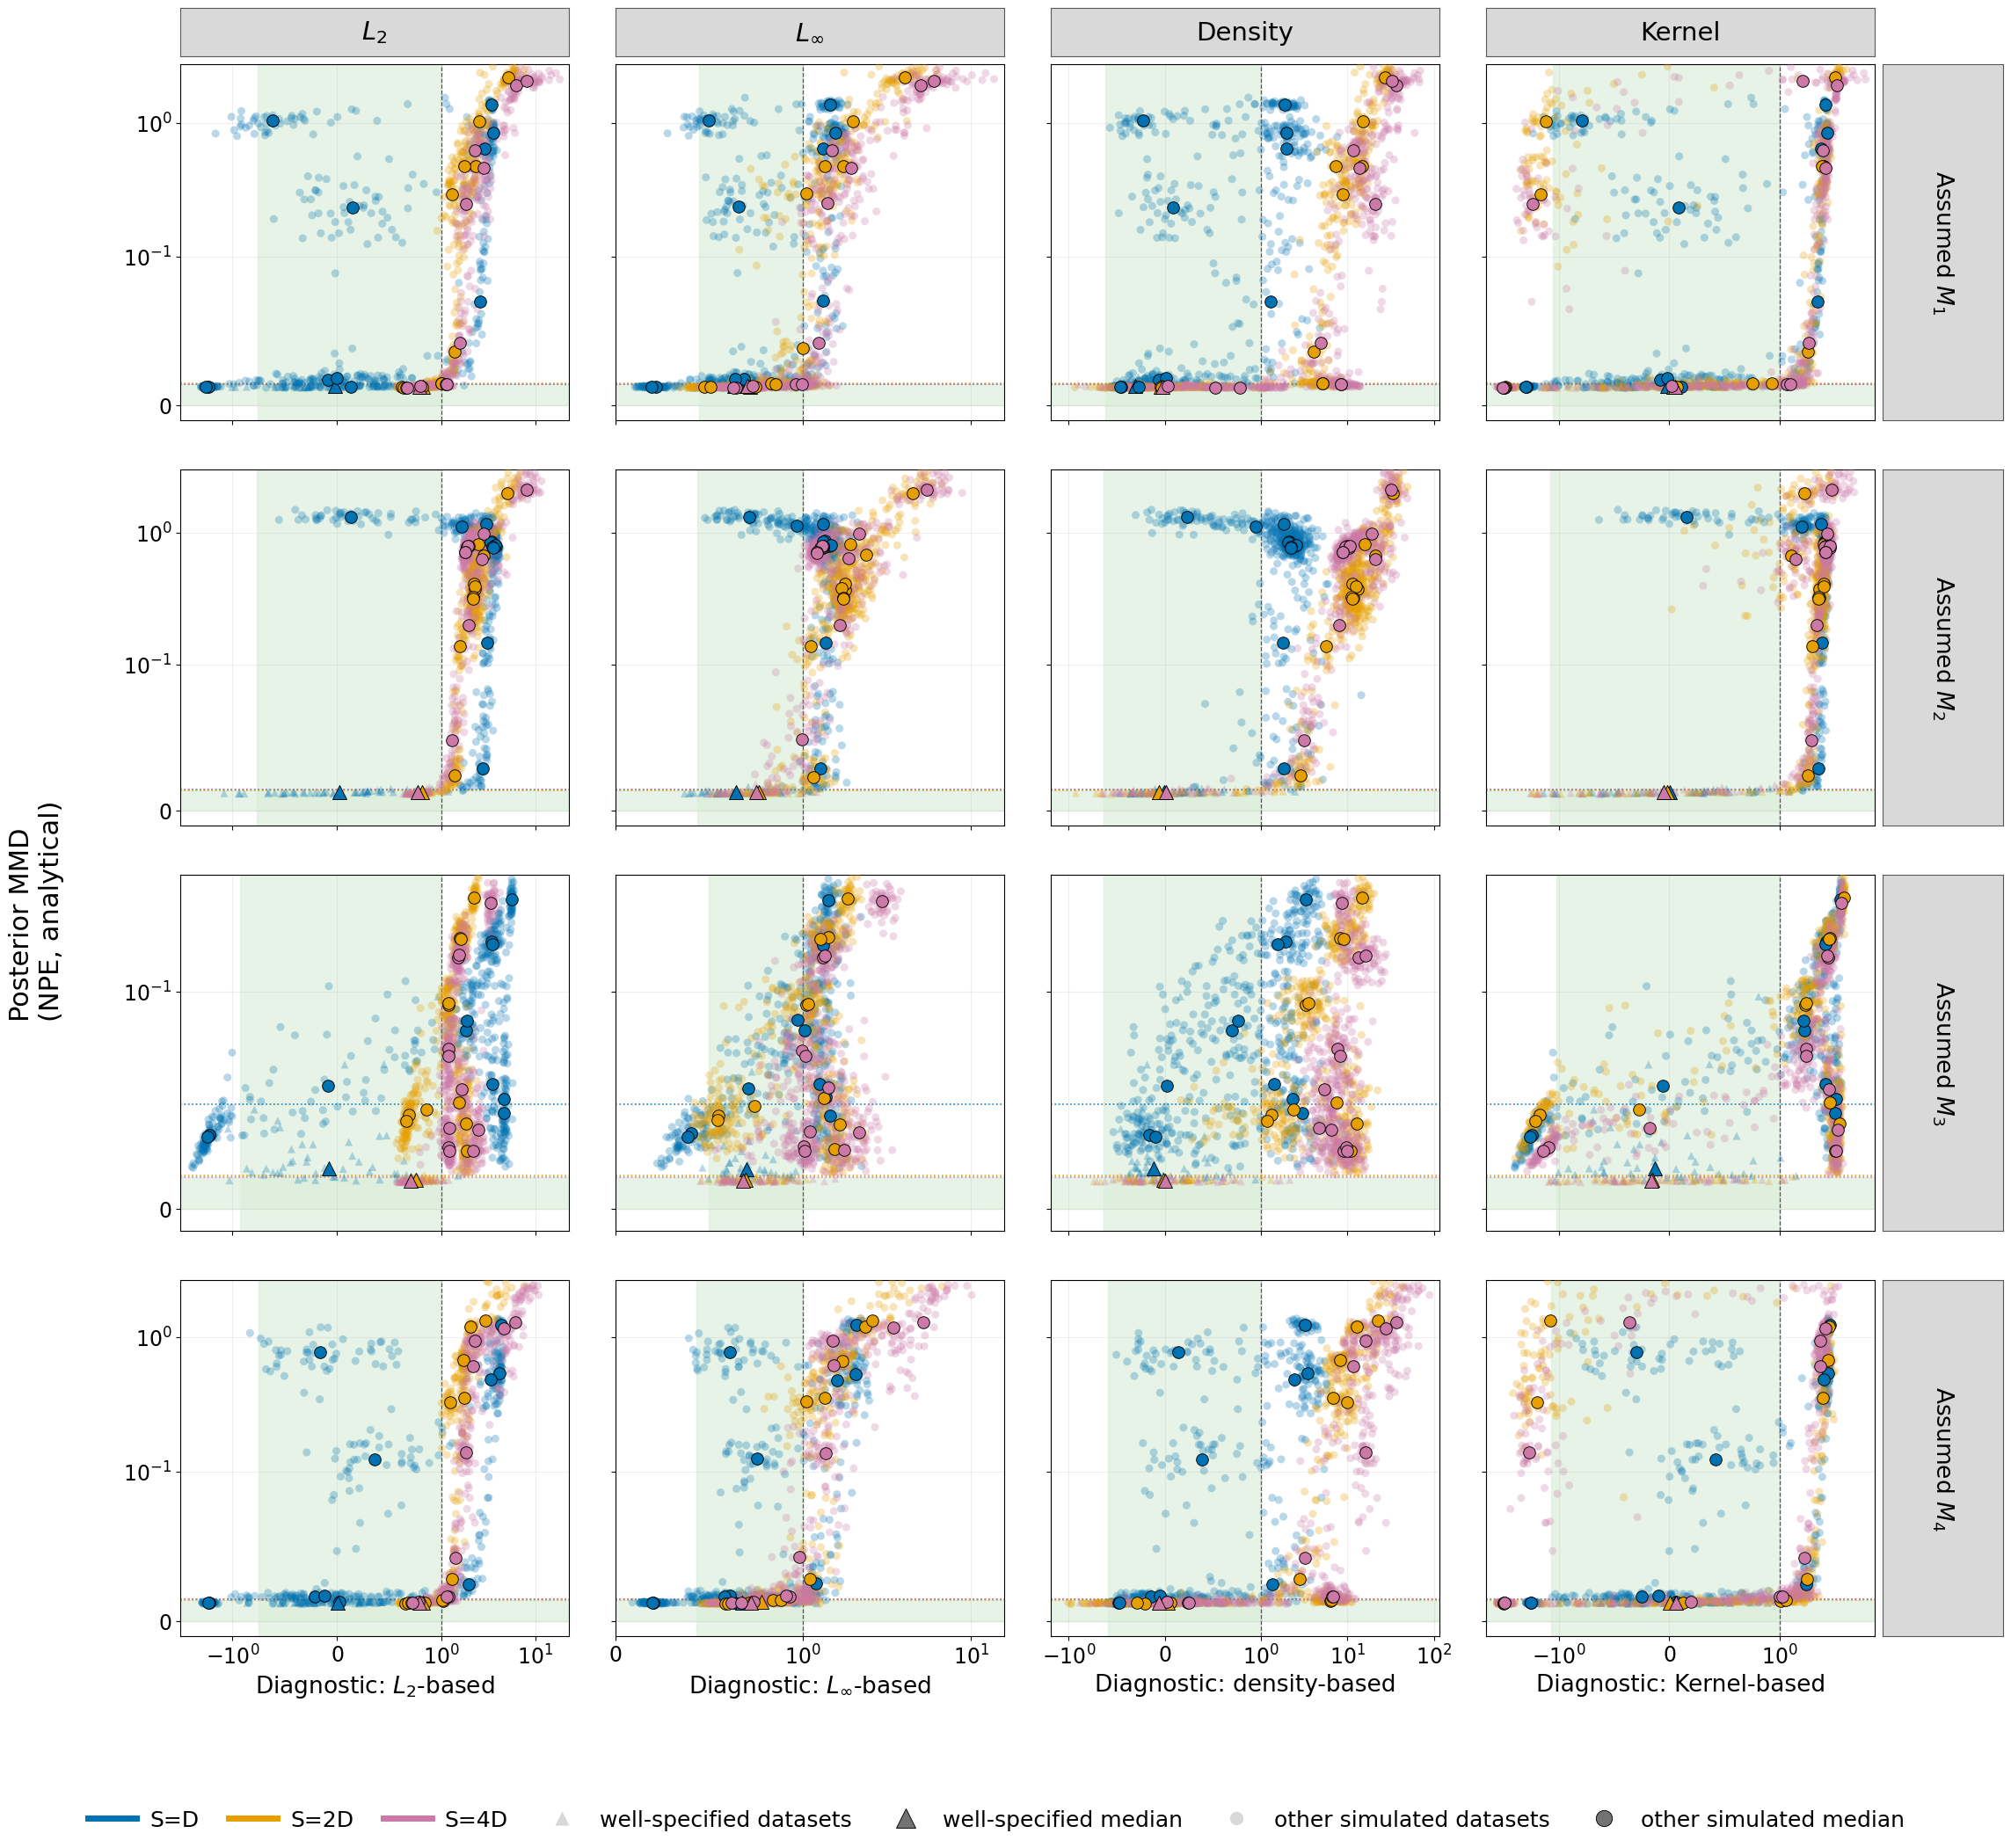

PosixPath('/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/plots/summary_dimension_M1_M4_4x4/posterior_mmd_M1_M4_by_diagnostic.png')

In [6]:
posterior_mmd_figure, posterior_mmd_axes, posterior_mmd_path = plot_metric_grid(
    "posterior_mmd",
    normalize_threshold=NORMALIZE_BY_CALIBRATION_THRESHOLD,
)
plt.show()
posterior_mmd_path

## Log10 marginal-likelihood error

Saved /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/plots/summary_dimension_M1_M4_4x4/log10_logml_error_M1_M4_by_diagnostic.png


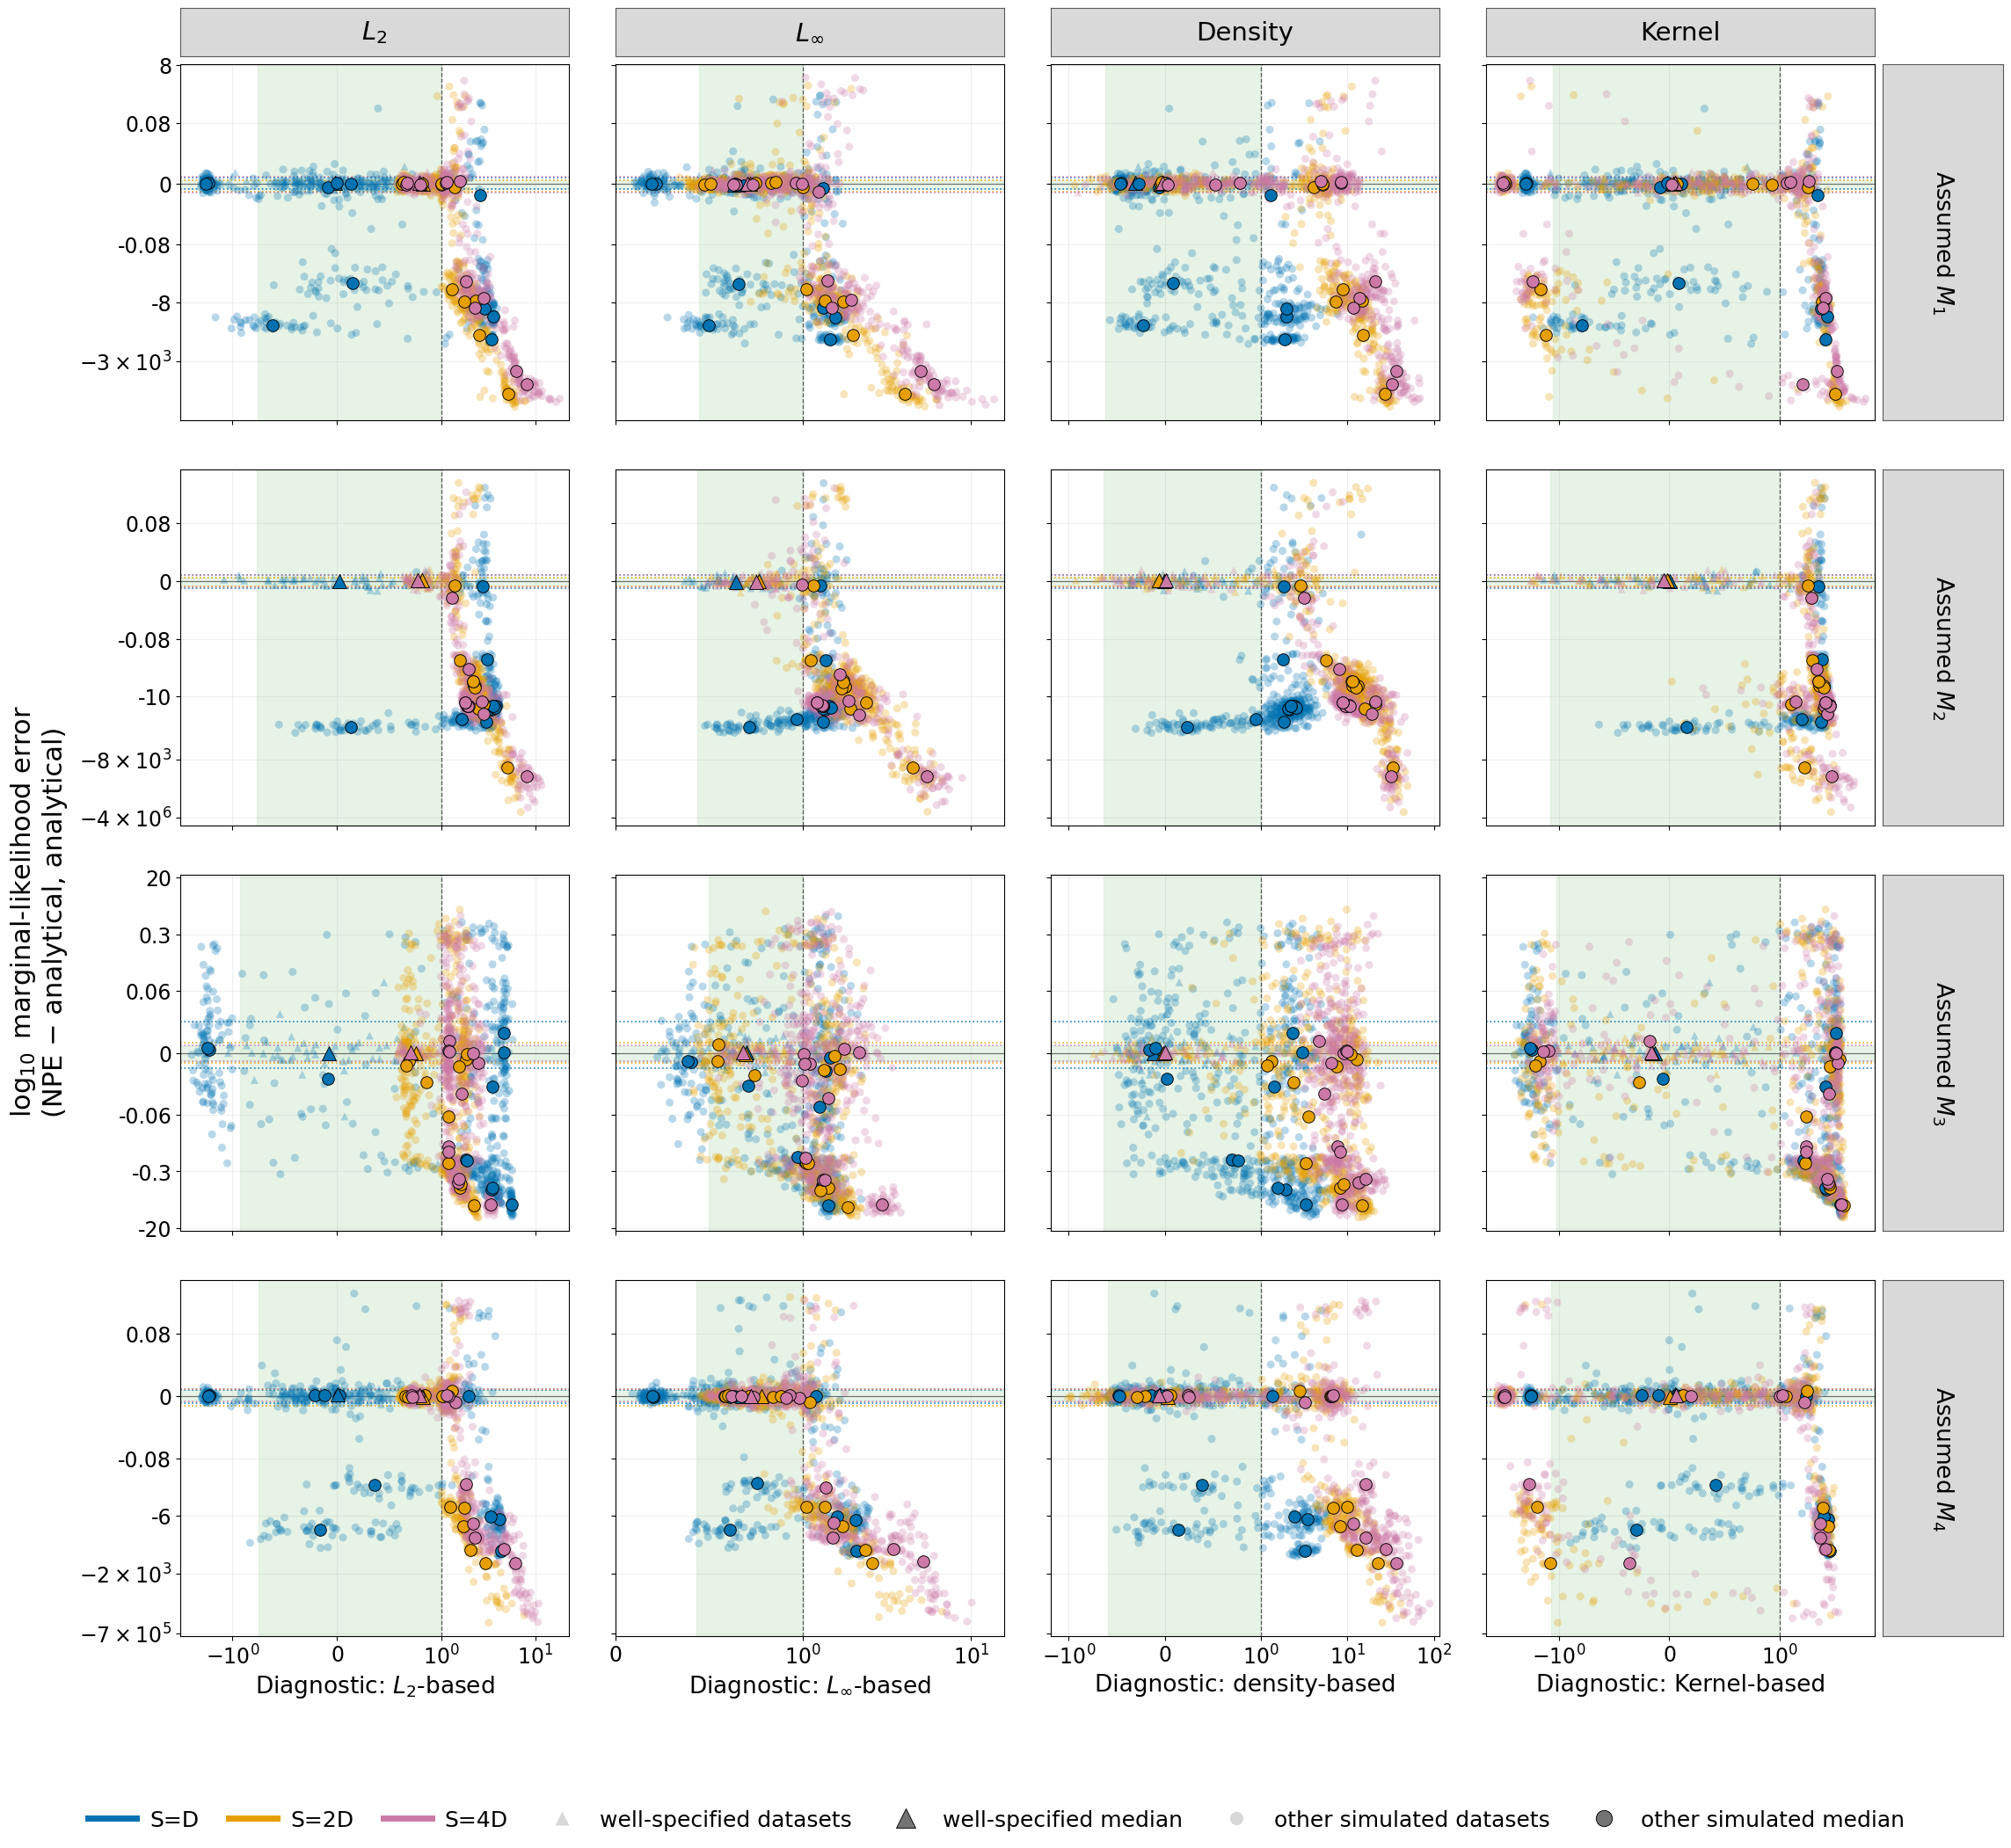

PosixPath('/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/plots/summary_dimension_M1_M4_4x4/log10_logml_error_M1_M4_by_diagnostic.png')

In [7]:
log10ml_figure, log10ml_axes, log10ml_path = plot_metric_grid(
    "log10_logml_error",
    normalize_threshold=NORMALIZE_BY_CALIBRATION_THRESHOLD,
)
plt.show()
log10ml_path

## PMP error

Saved /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/plots/summary_dimension_M1_M4_4x4/pmp_error_M1_M4_by_diagnostic.png


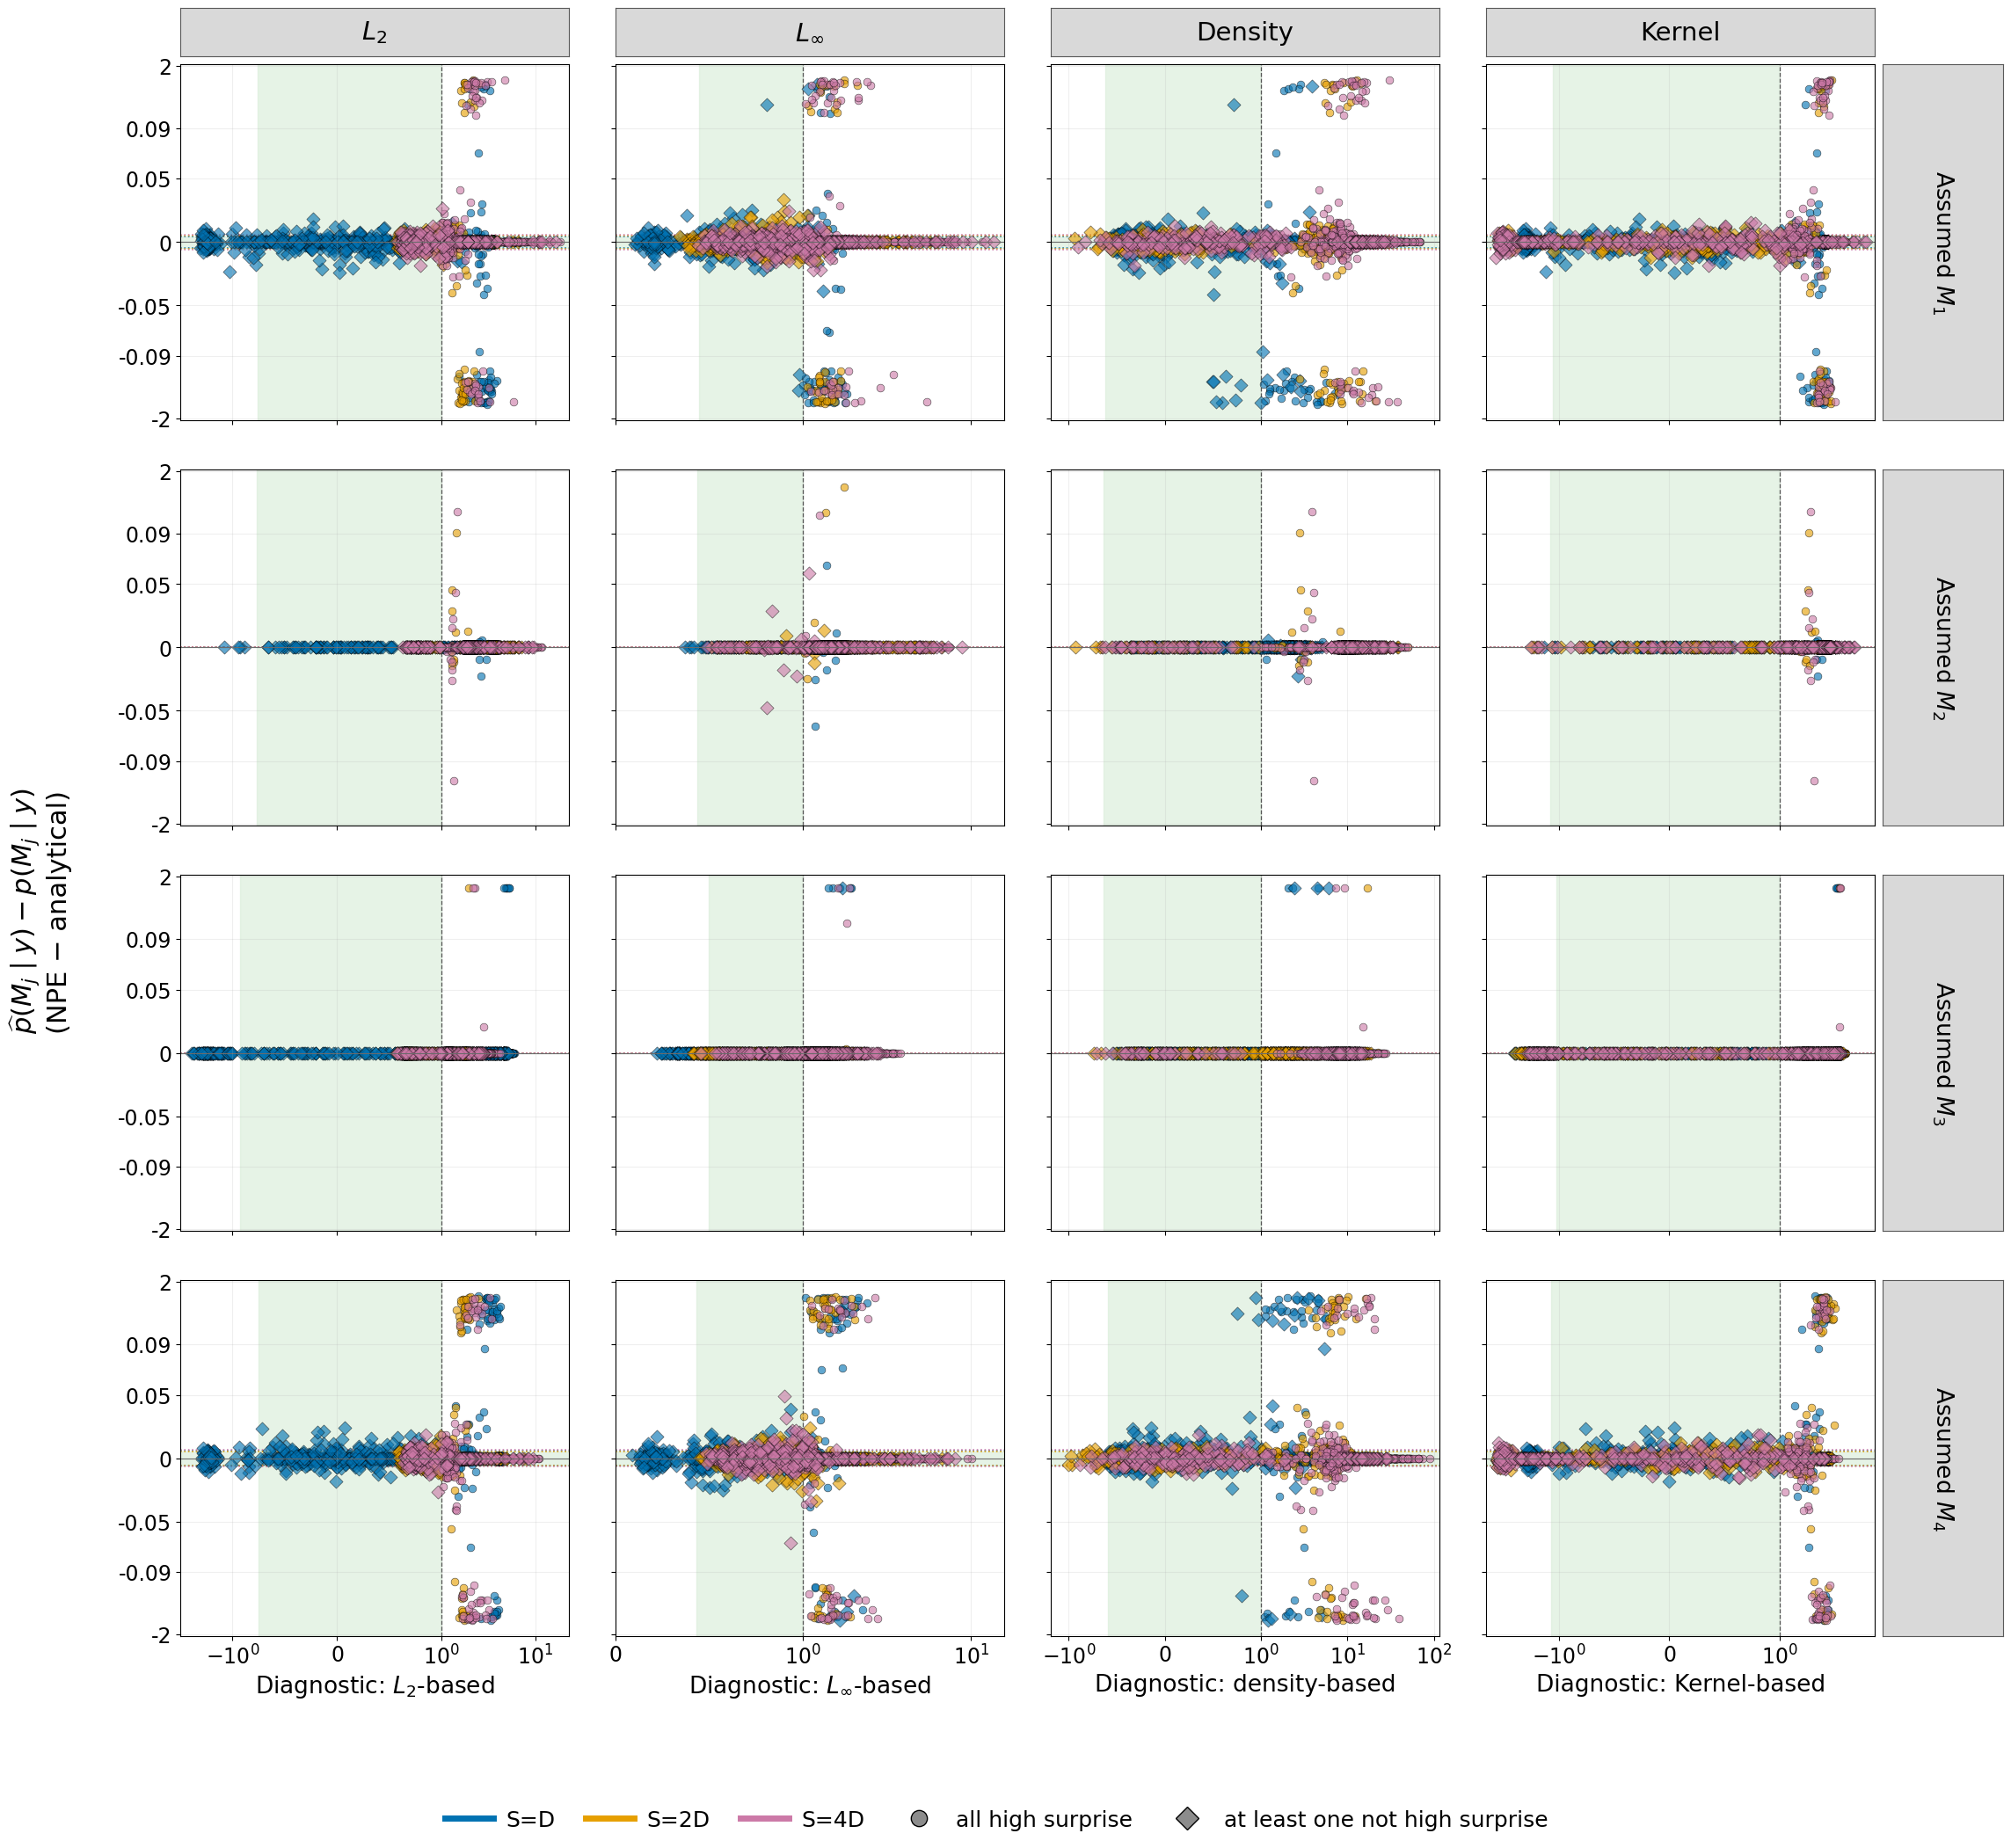

PosixPath('/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/plots/summary_dimension_M1_M4_4x4/pmp_error_M1_M4_by_diagnostic.png')

In [8]:
pmp_figure, pmp_axes, pmp_path = plot_metric_grid(
    "pmp_error",
    normalize_threshold=NORMALIZE_BY_CALIBRATION_THRESHOLD,
)
plt.show()
pmp_path